# Здесь будет обучение Temporal Fusion Transformer

In [1]:
import pandas as pd
import numpy as np

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import EncoderNormalizer
from pytorch_forecasting.metrics import RMSE

%cd ../..
import src.config as config

/home/financier/projects/bank-balance-pred


## 1. Грузим данные и настраиваем валидацию

Для данной архитектуры нам достаточно определить границу обучения через `time_idx`, который мы добавили как глобальный индекс времени в `src/targets/tft_dataset.py`.

Поэтому:

* **Validation/Test Set:** Последние 12 месяцев `time_idx`
* **Train Set:** Вся история до этого $:)$

In [2]:
df = pd.read_parquet(config.TFT_DS_PATH)

money_cols = config.TFT_TIME_VARYING_UNKNOWN_REALS.copy()
print(money_cols)

# добавил тк у меня градиенты взрывались
money_cols.remove("tenure_months")
for col in money_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

df["age"] = df["age"] / 100.0
df["trend_3"] = df["balance"] - df["lag_3"]

['balance', 'tenure_months', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3', 'roll_mean_6', 'roll_mean_12', 'roll_std_6', 'roll_min_12', 'roll_max_12', 'trend_3']


In [3]:
df.describe()

,report_date,balance,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_mean_12,roll_std_6,roll_min_12,roll_max_12,trend_3,age,tenure_months,time_idx
count,2695629,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06,2.695629e+06
mean,2024-05-03 09:13:29.570606,7.576765e+00,7.407003e+00,7.238155e+00,7.069929e+00,6.563303e+00,5.587132e+00,7.618824e+00,7.636460e+00,7.637130e+00,6.053576e+00,7.214992e+00,7.828598e+00,5.068356e-01,4.115484e-01,5.844411e+01,2.709733e+01
min,2022-01-31 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.644029e+01,2.000000e-01,0.000000e+00,0.000000e+00
25%,2023-04-30 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.327225e-02,3.100000e-01,3.100000e+01,1.500000e+01
50%,2024-05-31 00:00:00,1.022198e+01,1.018494e+01,1.014254e+01,1.010238e+01,9.947553e+00,9.314791e+00,1.023283e+01,1.023701e+01,1.023851e+01,8.071691e+00,9.985114e+00,1.049960e+01,0.000000e+00,4.100000e-01,5.800000e+01,2.800000e+01
75%,2025-05-31 00:00:00,1.103973e+01,1.101865e+01,1.099710e+01,1.097509e+01,1.089490e+01,1.072988e+01,1.104400e+01,1.104294e+01,1.104134e+01,9.049905e+00,1.081378e+01,1.131692e+01,8.681393e-02,5.100000e-01,8.400000e+01,4.000000e+01
max,2026-04-30 00:00:00,1.757242e+01,1.757242e+01,1.757242e+01,1.757242e+01,1.757242e+01,1.757242e+01,1.741625e+01,1.741625e+01,1.741625e+01,1.689227e+01,1.741625e+01,1.757242e+01,1.741625e+01,7.900000e-01,1.350000e+02,5.100000e+01
std,NaN,5.097195e+00,5.163333e+00,5.222788e+00,5.275980e+00,5.397147e+00,5.503130e+00,5.079129e+00,5.070897e+00,5.070816e+00,4.230240e+00,5.098019e+00,5.195914e+00,2.551732e+00,1.237621e-01,3.304098e+01,1.490107e+01


In [4]:
max_prediction_length = config.TFT_MAX_PREDICTION_LENGTH
max_encoder_length = config.TFT_MAX_ENCODER_LENGTH

training_cutoff = df[config.TFT_TIME_IDX].max() - max_prediction_length

In [5]:
df.isna().sum()

client_id        0
report_date      0
product          0
balance          0
lag_1            0
lag_2            0
lag_3            0
lag_6            0
lag_12           0
roll_mean_3      0
roll_mean_6      0
roll_mean_12     0
roll_std_6       0
roll_min_12      0
roll_max_12      0
trend_3          0
month            0
quarter          0
is_december      0
is_summer        0
gender           0
age              0
segment          0
region           0
is_salary        0
tenure_months    0
time_idx         0
dtype: int64

## 2. TimeSeriesDataSet

In [6]:
from pytorch_forecasting.data.encoders import NaNLabelEncoder

training = TimeSeriesDataSet(
    df[lambda x: x[config.TFT_TIME_IDX] <= training_cutoff],
    time_idx=config.TFT_TIME_IDX,
    target=config.TFT_TARGET,
    group_ids=config.TFT_GROUP_IDS,

    min_encoder_length=max_encoder_length // 4,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,

    static_categoricals=config.TFT_STATIC_CATEGORICALS,
    static_reals=config.TFT_STATIC_REALS,
    time_varying_known_categoricals=config.TFT_TIME_VARYING_KNOWN_CATEGORICALS,
    time_varying_unknown_reals=config.TFT_TIME_VARYING_UNKNOWN_REALS,

    target_normalizer=EncoderNormalizer(transformation="relu"),

    categorical_encoders={"client_id": NaNLabelEncoder(add_nan=True)},
    
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)

/home/financier/projects/bank-balance-pred/.venv/lib/python3.11/site-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 1074 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__client_id': '10109', '__group_id__product': 'card'}, {'__group_id__client_id': '10109', '__group_id__product': 'deposit'}, {'__group_id__client_id': '10109', '__group_id__product': 'savings'}, {'__group_id__client_id': '10118', '__group_id__product': 'card'}, {'__group_id__client_id': '10118', '__group_id__product': 'deposit'}, {'__group_id__client_id': '10118', '__group_id__product': 'savings'}, {'__group_id__client_id': '10254', '__group_id__product': 'card'}, {'__group_id__client_id': '10254', '__group_id__product': 'deposit'}, {'__group_id__client_id': '10254', '__grou

In [7]:
batch_size = 2048
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=12
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 2, num_workers=12
)

## 3. Обучение TFT

Так как pytorch_forecasting основан на pytorch_lightning, то и цикл обучения я буду писать на lightning $:)$

In [10]:
from pytorch_forecasting.metrics import QuantileLoss

early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=3, verbose=True, mode="min"
)

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="gpu",
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=1.0,
    callbacks=[early_stop_callback],
    logger=False,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.01,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=2,
)

print(f"Количество параметров модели: {tft.size() / 1000:.1f}тысяч")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Количество параметров модели: 358.5тысяч


In [11]:
import warnings
import torch

warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision('medium')

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 134    | train | 0    
3  | prescalers                         | ModuleDict                      | 1.2 K  | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 29.4 K | train | 0    
5  | encoder_variable_selection         | VariableSel

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.093


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.093


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


## 4. Оценка качества модели

Модель обучена предсказывать 7 квантилей, по сути доверительных интервалов. Поэтому в качестве финального точечного прогноза я возьму медиану.

In [15]:
output = tft.predict(val_dataloader, mode="prediction", return_x=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [22]:
preds_tensor = output.output
x_dict = output.x
log_actuals = x_dict["decoder_target"]

preds_np = preds_tensor.detach().cpu().numpy()
actuals_np = log_actuals.detach().cpu().numpy()

preds_rub = np.expm1(preds_np.clip(min=0))
actuals_rub = np.expm1(actuals_np.clip(min=0))

In [25]:
def calculate_wape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))).item() * 100

In [26]:
horizon_metrics = []

for h in range(config.TFT_MAX_PREDICTION_LENGTH):
    y_true_h = actuals_rub[:, h]
    y_pred_h = preds_rub[:, h]
    
    # Считаем метрики
    mae_val = np.mean(np.abs(y_true_h - y_pred_h)).item()
    wape_val = calculate_wape(y_true_h, y_pred_h)
    
    horizon_metrics.append({
        'Горизонт (мес)': h + 1,
        'TFT MAE': round(mae_val, 2),
        'TFT WAPE %': round(wape_val, 3)
    })

In [28]:
metrics_df = pd.DataFrame(horizon_metrics)
print("Долгожданные метрики !!")
display(metrics_df)

Долгожданные метрики !!


,Горизонт (мес),TFT MAE,TFT WAPE %
0,1,10515.35,10.143
1,2,11045.00,11.183
2,3,11520.18,11.734
3,4,10803.86,11.016
4,5,11634.18,11.235
5,6,11548.23,11.166
6,7,12090.55,11.688
7,8,15516.62,11.460
8,9,11694.94,11.247
9,10,11343.77,10.931


## 5. Графики с интерпретациями

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


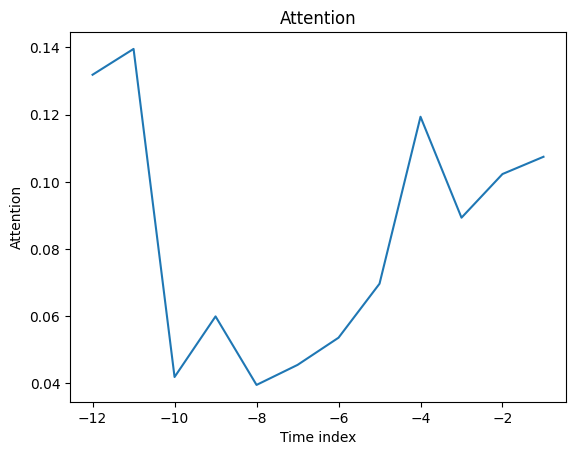

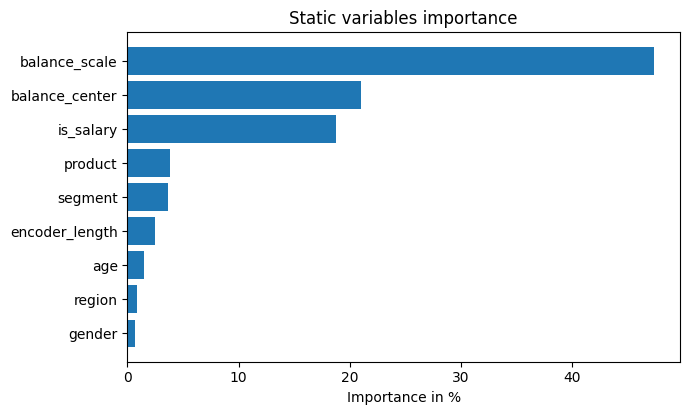

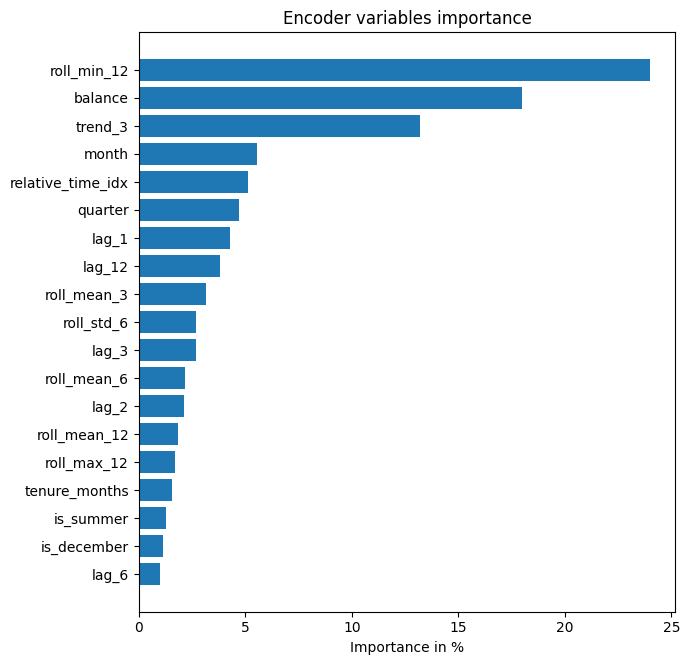

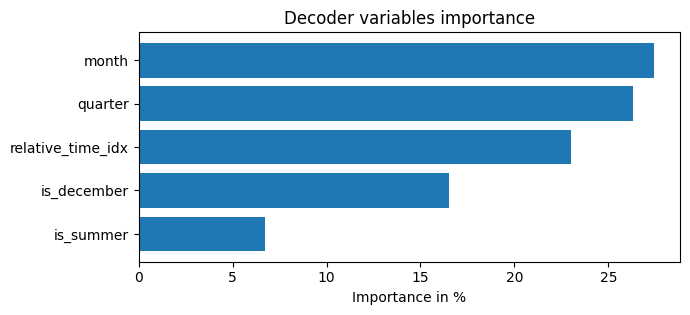

In [30]:
raw_preds = tft.predict(val_dataloader, mode="raw", return_x=True)
interpretation = tft.interpret_output(raw_preds.output, reduction="sum")

figs = tft.plot_interpretation(interpretation)

## 6. Визуализации конкретных прогнозов с доверительными интервалами !!

Поскольку мы обучали модель с `QuantileLoss`, она предсказывает не только одну точку, а именно квантили, то есть уверенность в ответах